# PCAoiv - decathlon dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## decathlon dataset

In [2]:
# decathlon dataset
from scientisttools.datasets import decathlon
decathlon._fields

('actif', 'ind_sup', 'sup_var', 'data')

In [3]:
# overall dataset
data = decathlon.data.iloc[:41,:].drop(columns=["Rank"])
data.info()

<class 'pandas.DataFrame'>
Index: 41 entries, SEBRLE to Casarsa
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X100m         41 non-null     float64
 1   Long.Jump     41 non-null     float64
 2   Shot.Put      41 non-null     float64
 3   High.Jump     41 non-null     float64
 4   X400m         41 non-null     float64
 5   X110m.Hurdle  41 non-null     float64
 6   Discus        41 non-null     float64
 7   Pole.Vault    41 non-null     float64
 8   Javeline      41 non-null     float64
 9   X1500m        41 non-null     float64
 10  Points        41 non-null     int64  
 11  Competition   41 non-null     str    
dtypes: float64(10), int64(1), str(1)
memory usage: 4.2+ KB


## Instanciation and training

In [4]:
from scientisttools import PCA
# instanciation
clf = PCA(iv=(10,11),ortho=True)

## `fit` function

In [5]:
#fit
clf.fit(data)

,iv,"(10, ...)"
,ortho,True
,scale_unit,True
,partial,None
,group,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None


## `fit_transform` function

In [6]:
#fit_transform - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
SEBRLE,0.830429,0.357013,1.159097,0.086348,1.210317
CLAY,0.682324,2.155342,-0.353584,-2.367900,-0.508816
KARPOV,0.620661,2.014828,-1.650821,0.496692,-0.733025
BERNARD,-0.861129,0.195334,2.439503,-0.150877,-0.112780
YURKOV,2.123507,-1.805207,0.848381,0.599318,0.235727
WARNERS,-1.610440,0.627800,-0.504561,0.670781,0.001557
ZSIVOCZKY,-1.050959,-1.196789,-1.881038,-0.392869,-0.122734
McMULLEN,0.293994,-0.276618,-1.776139,0.159172,1.759533
MARTINEAU,0.552322,-1.275708,0.010888,1.126412,-2.410472
HERNU,0.513951,0.425042,0.638362,-0.801191,-0.063248


### `transform` function

In [7]:
# transform function - individuals coordinates
ind_coord = clf.transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
SEBRLE,0.830429,0.357013,1.159097,0.086348,1.210317
CLAY,0.682324,2.155342,-0.353584,-2.367900,-0.508816
KARPOV,0.620661,2.014828,-1.650821,0.496692,-0.733025
BERNARD,-0.861129,0.195334,2.439503,-0.150877,-0.112780
YURKOV,2.123507,-1.805207,0.848381,0.599318,0.235727
WARNERS,-1.610440,0.627800,-0.504561,0.670781,0.001557
ZSIVOCZKY,-1.050959,-1.196789,-1.881038,-0.392869,-0.122734
McMULLEN,0.293994,-0.276618,-1.776139,0.159172,1.759533
MARTINEAU,0.552322,-1.275708,0.010888,1.126412,-2.410472
HERNU,0.513951,0.425042,0.638362,-0.801191,-0.063248


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Principal Component Analysis (PCA)**

*The results are available in the following objects:

name          description
------------  -----------------------------------------------------
.call_        summary called parameters
.eig_         eigenvalues
.ind_         results for the individuals
.quanti_var_  results for the quantitative variables
.svd_         results for generalized singular values decomposition



## Eigen values

In [9]:
#eigen values
from scientisttools import get_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,1.736915,0.339596,26.058139,26.058139
Dim2,1.397319,0.209555,20.963333,47.021473
Dim3,1.187764,0.545118,17.819474,64.840946
Dim4,0.642646,0.040401,9.641316,74.482263
Dim5,0.602245,0.185652,9.035199,83.517461
Dim6,0.416593,0.084614,6.249952,89.767413
Dim7,0.331979,0.125692,4.980527,94.747939
Dim8,0.206287,0.062684,3.094827,97.842767
Dim9,0.143603,0.143416,2.154415,99.997182
Dim10,0.000188,NaN,0.002818,100.000000


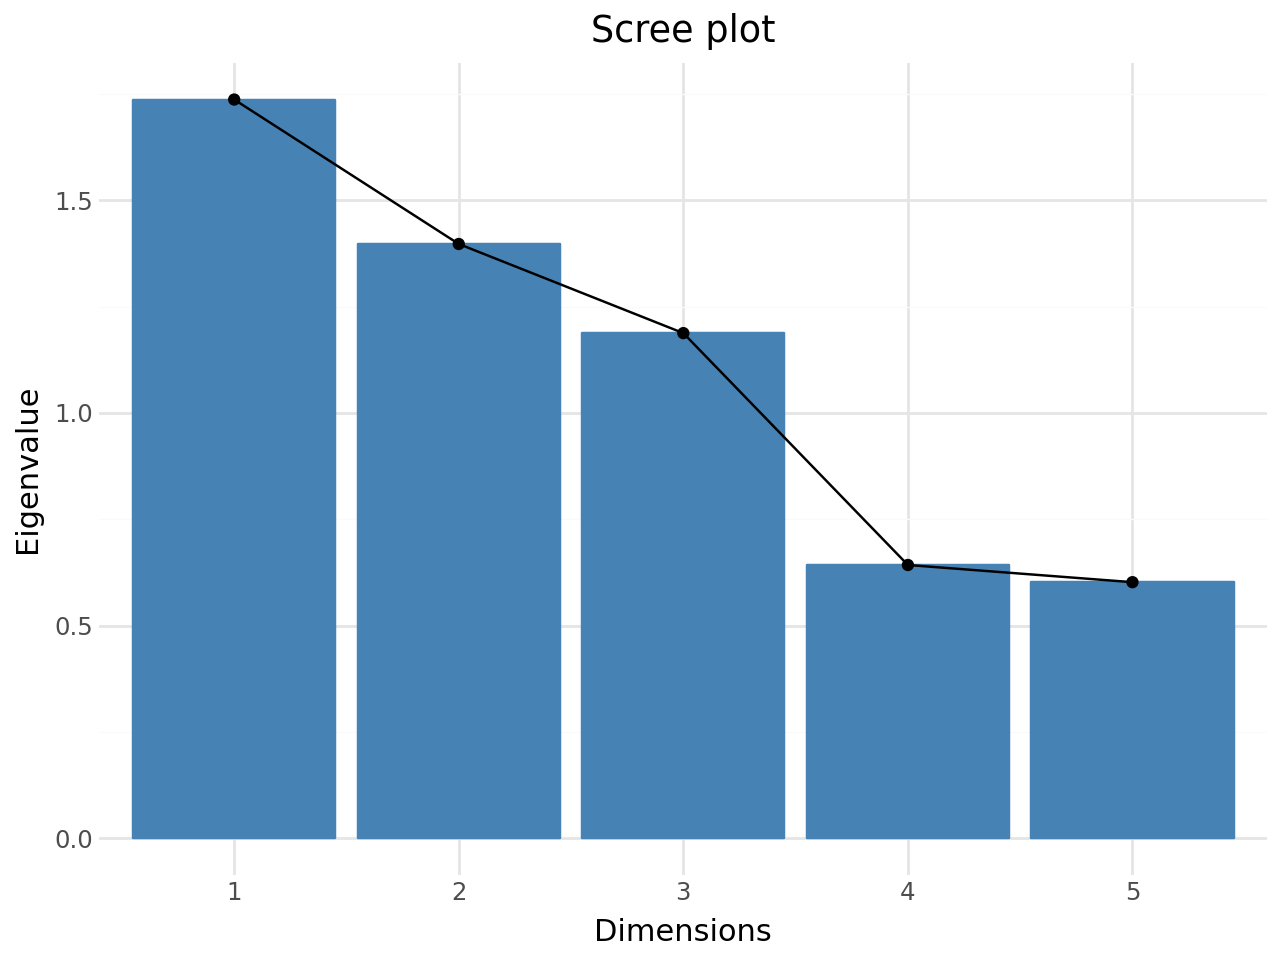

None


In [10]:
# scree plot
from scientisttools import fviz_screeplot
p = fviz_screeplot(clf,choice="eigenvalue")
print(p.show())

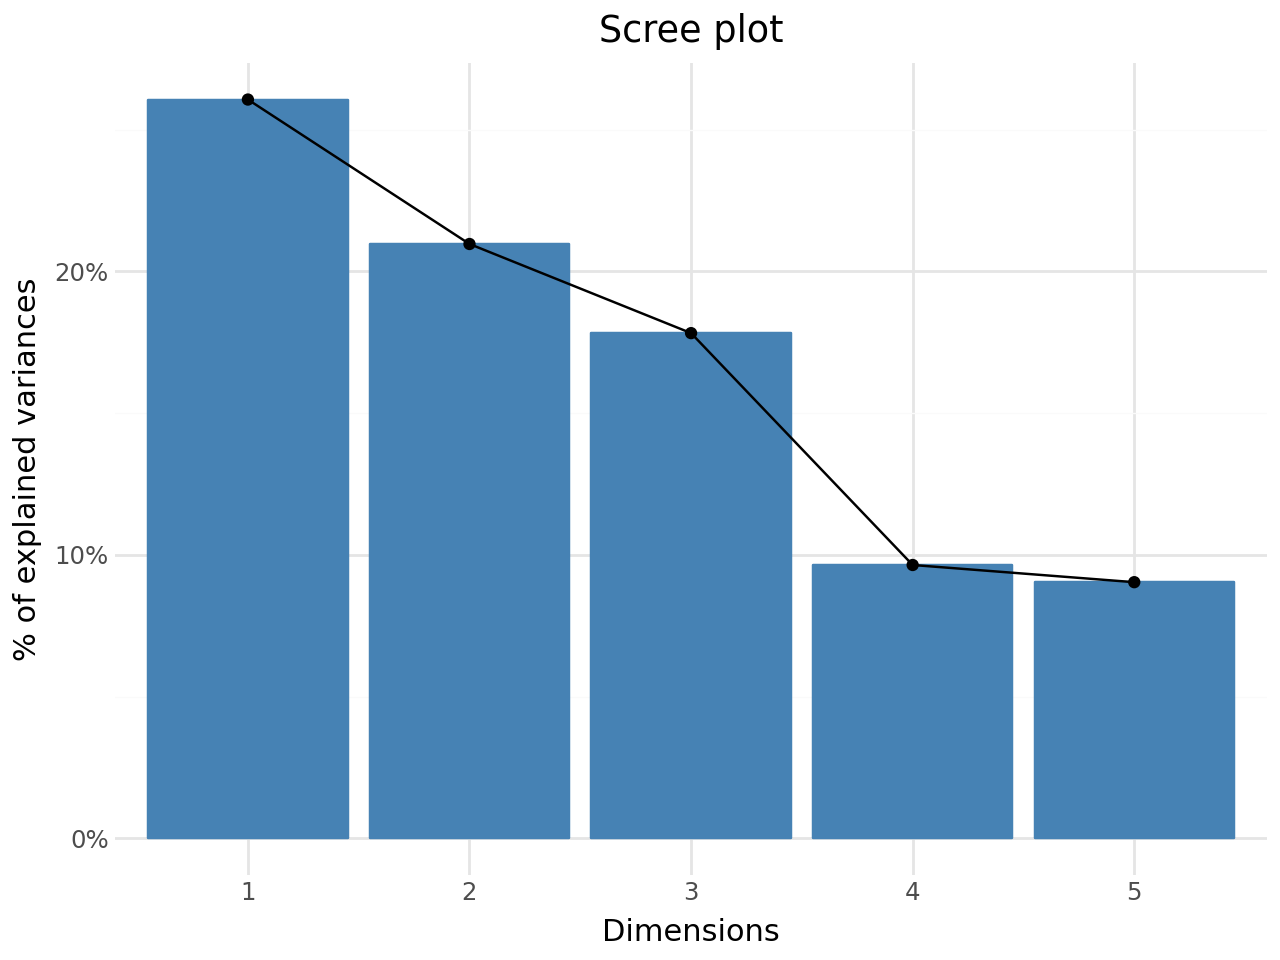

None


In [11]:
# proportion
p = fviz_screeplot(clf,choice="proportion")
print(p.show())

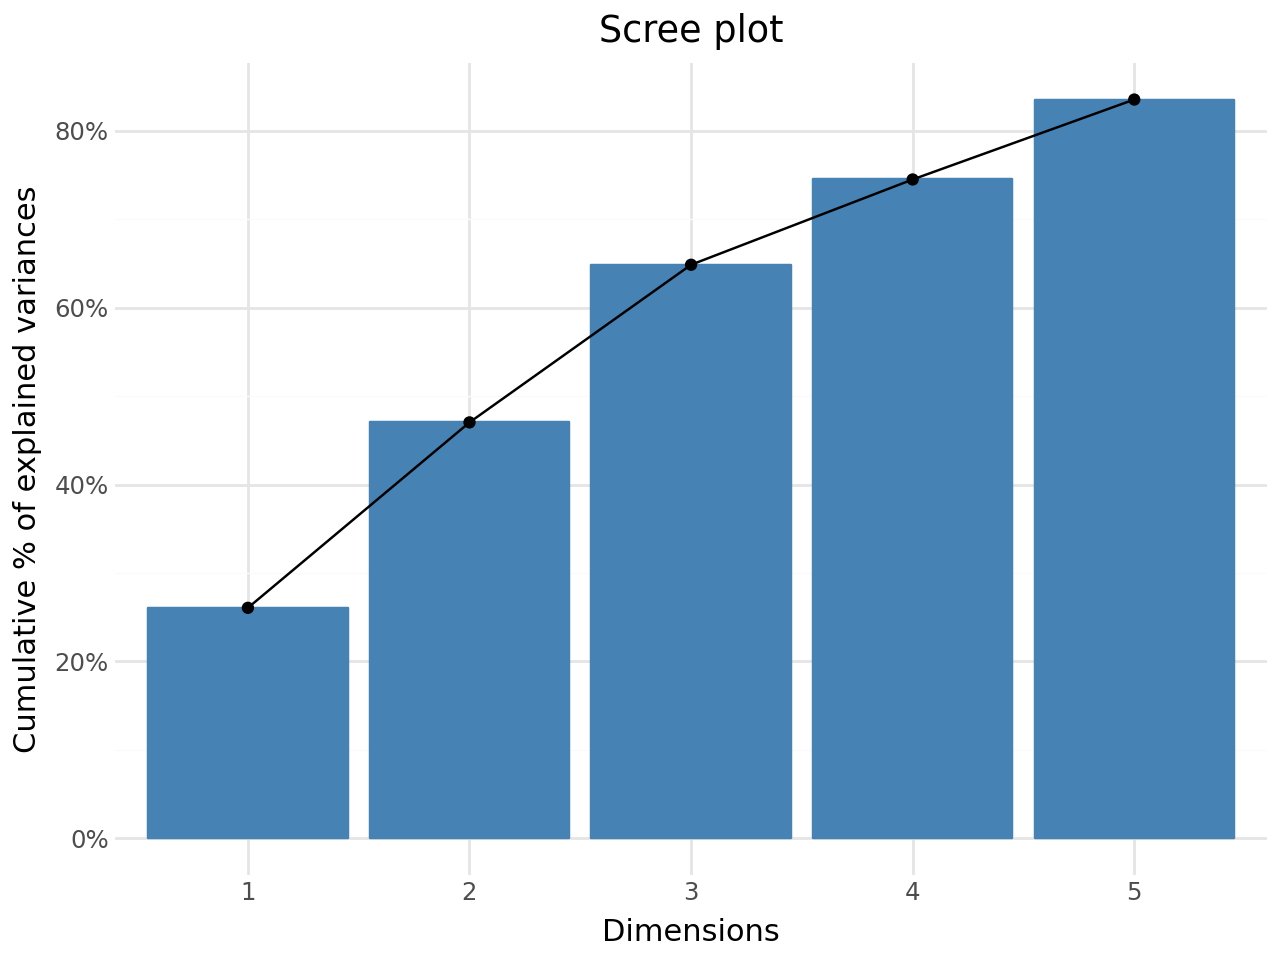

None


In [12]:
# cumulative proportion
p = fviz_screeplot(clf,choice="cumulative")
print(p.show())

## Individuals informations

In [13]:
#individuals informations
from scientisttools import get_pca
ind = get_pca(clf,"ind")
ind._fields

('coord', 'cos2', 'contrib', 'infos')

### Individuals coordinates

In [14]:
# individuals coordinates
ind.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
SEBRLE,0.830429,0.357013,1.159097,0.086348,1.210317
CLAY,0.682324,2.155342,-0.353584,-2.367900,-0.508816
KARPOV,0.620661,2.014828,-1.650821,0.496692,-0.733025
BERNARD,-0.861129,0.195334,2.439503,-0.150877,-0.112780
YURKOV,2.123507,-1.805207,0.848381,0.599318,0.235727
WARNERS,-1.610440,0.627800,-0.504561,0.670781,0.001557
ZSIVOCZKY,-1.050959,-1.196789,-1.881038,-0.392869,-0.122734
McMULLEN,0.293994,-0.276618,-1.776139,0.159172,1.759533
MARTINEAU,0.552322,-1.275708,0.010888,1.126412,-2.410472
HERNU,0.513951,0.425042,0.638362,-0.801191,-0.063248


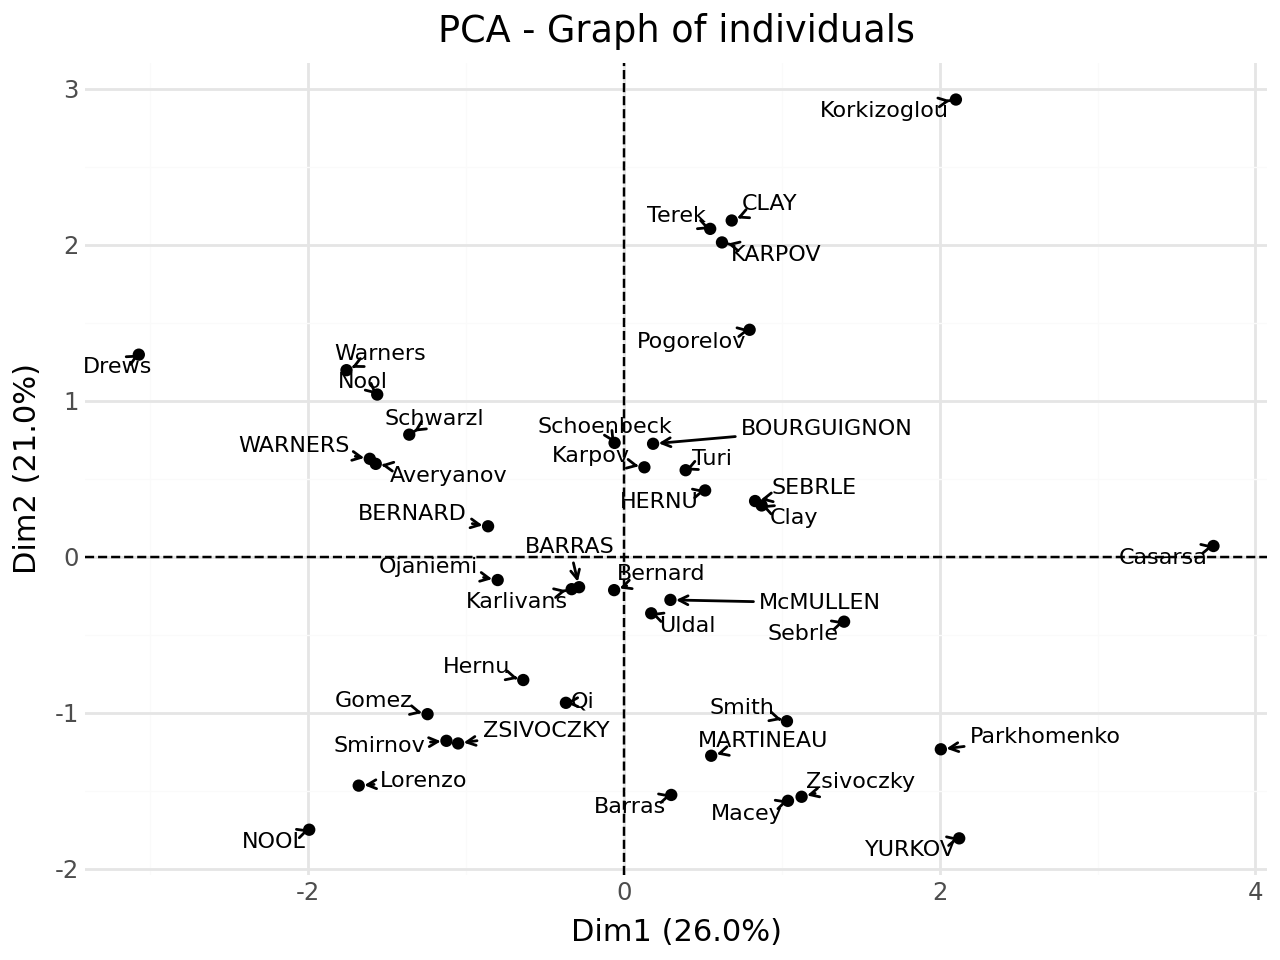

None


In [15]:
# graph of individuals
from scientisttools import fviz_pca
p = fviz_pca(
    obj=clf,
    choice="ind",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

### Individuals contributions

In [16]:
# individuals contributions
ind.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
SEBRLE,0.968372,0.222479,2.758837,0.028297,5.932551
CLAY,0.653761,8.108732,0.256727,21.279985,1.048491
KARPOV,0.540936,7.085927,5.596110,0.936308,2.176108
BERNARD,1.041295,0.066600,12.220491,0.086395,0.051512
YURKOV,6.332060,5.688199,1.477978,1.363201,0.225040
WARNERS,3.641889,0.687960,0.522773,1.707681,0.000010
ZSIVOCZKY,1.550990,2.500089,7.265762,0.585787,0.061006
McMULLEN,0.121371,0.133562,6.477989,0.096156,12.538281
MARTINEAU,0.428373,2.840685,0.000243,4.815475,23.531378
HERNU,0.370921,0.315343,0.836796,2.436220,0.016201


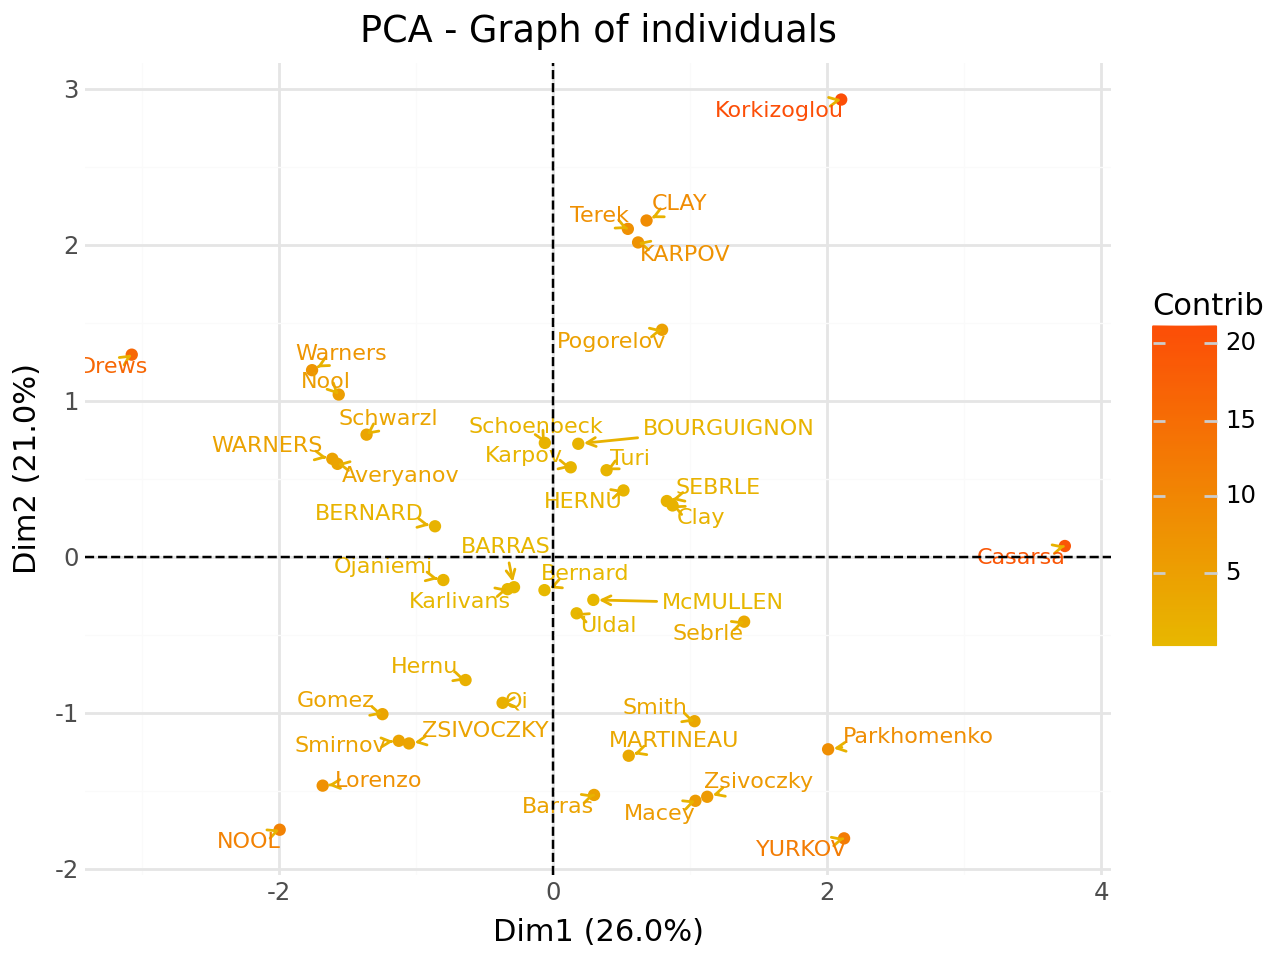

None


In [17]:
# graph of individuals - color by contributions
p = fviz_pca(
    obj=clf,
    choice="ind",
    col_ind="contrib",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

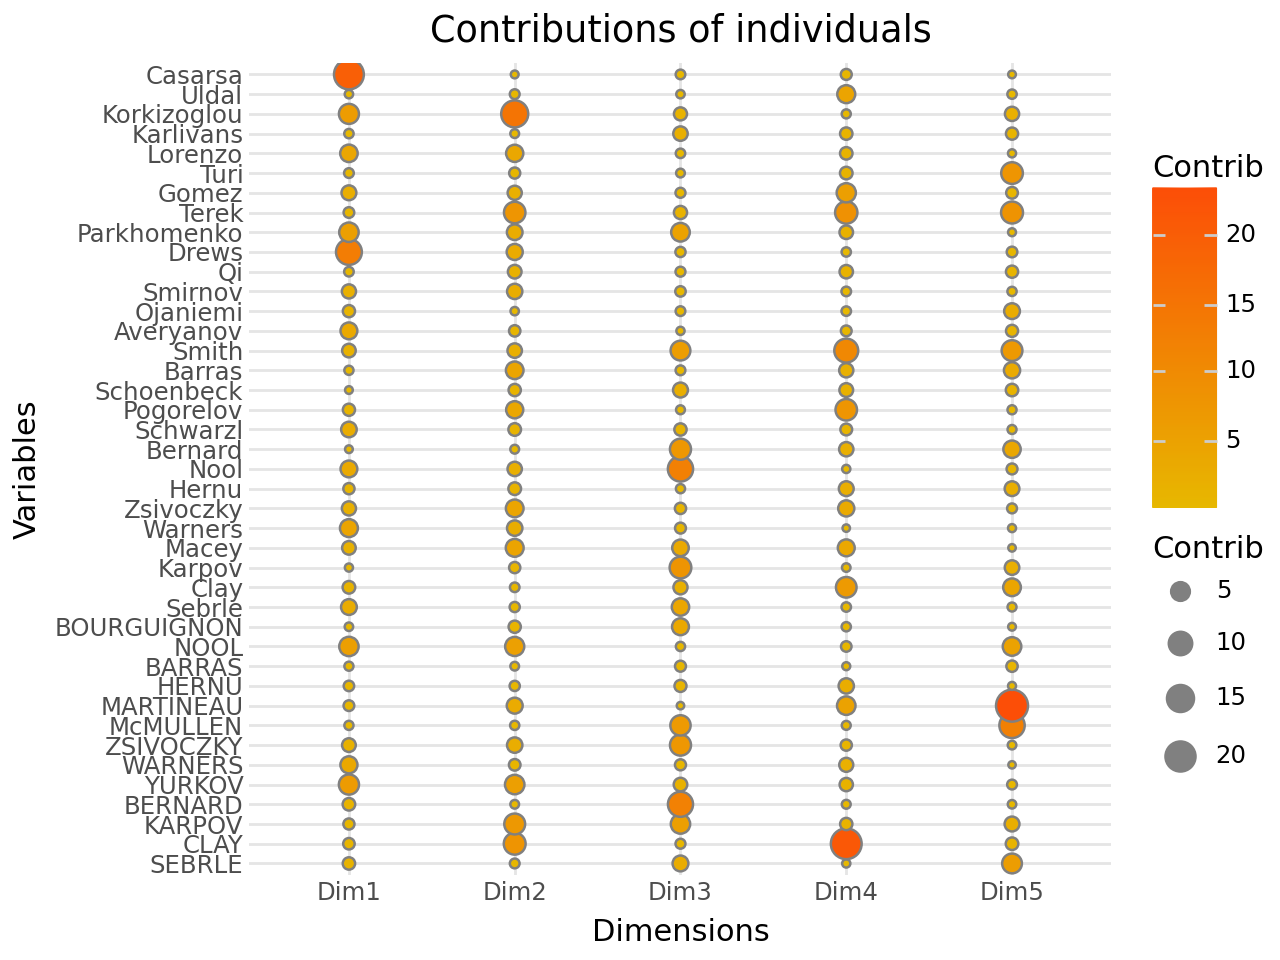

None


In [18]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

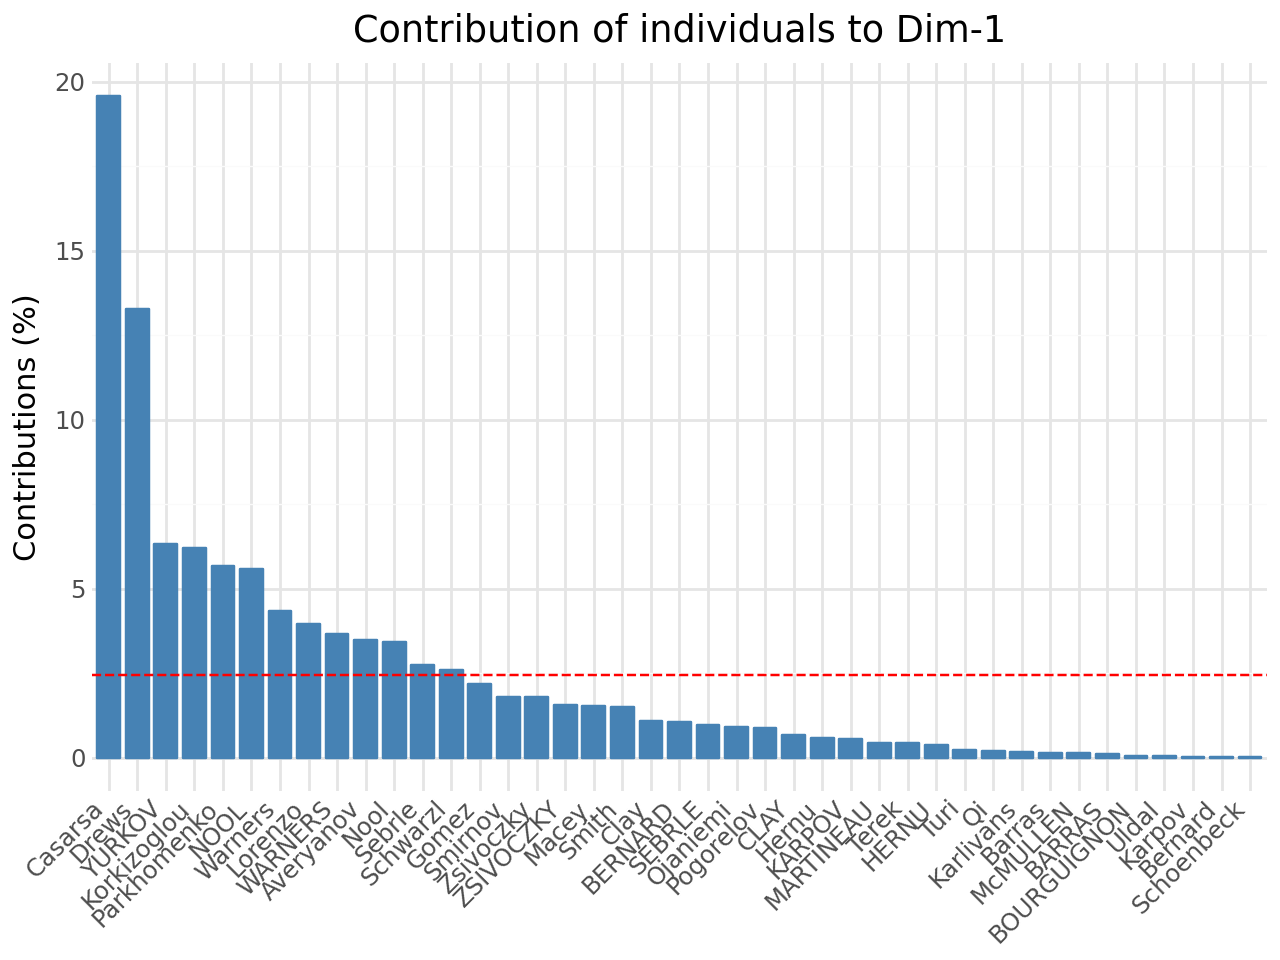

None


In [19]:
# contributions of individuals to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals cos2

In [20]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
SEBRLE,0.181669,0.033577,0.353928,0.001964,3.858988e-01
CLAY,0.040074,0.399863,0.010761,0.482620,2.228435e-02
KARPOV,0.044819,0.472310,0.317067,0.028703,6.251561e-02
BERNARD,0.099130,0.005101,0.795560,0.003043,1.700345e-03
YURKOV,0.496401,0.358740,0.079233,0.039540,6.117050e-03
WARNERS,0.553392,0.084098,0.054321,0.096008,5.174479e-07
ZSIVOCZKY,0.167086,0.216672,0.535258,0.023349,2.278739e-03
McMULLEN,0.011846,0.010487,0.432352,0.003472,4.243053e-01
MARTINEAU,0.030491,0.162662,0.000012,0.126817,5.807481e-01
HERNU,0.053656,0.036698,0.082777,0.130392,8.125881e-04


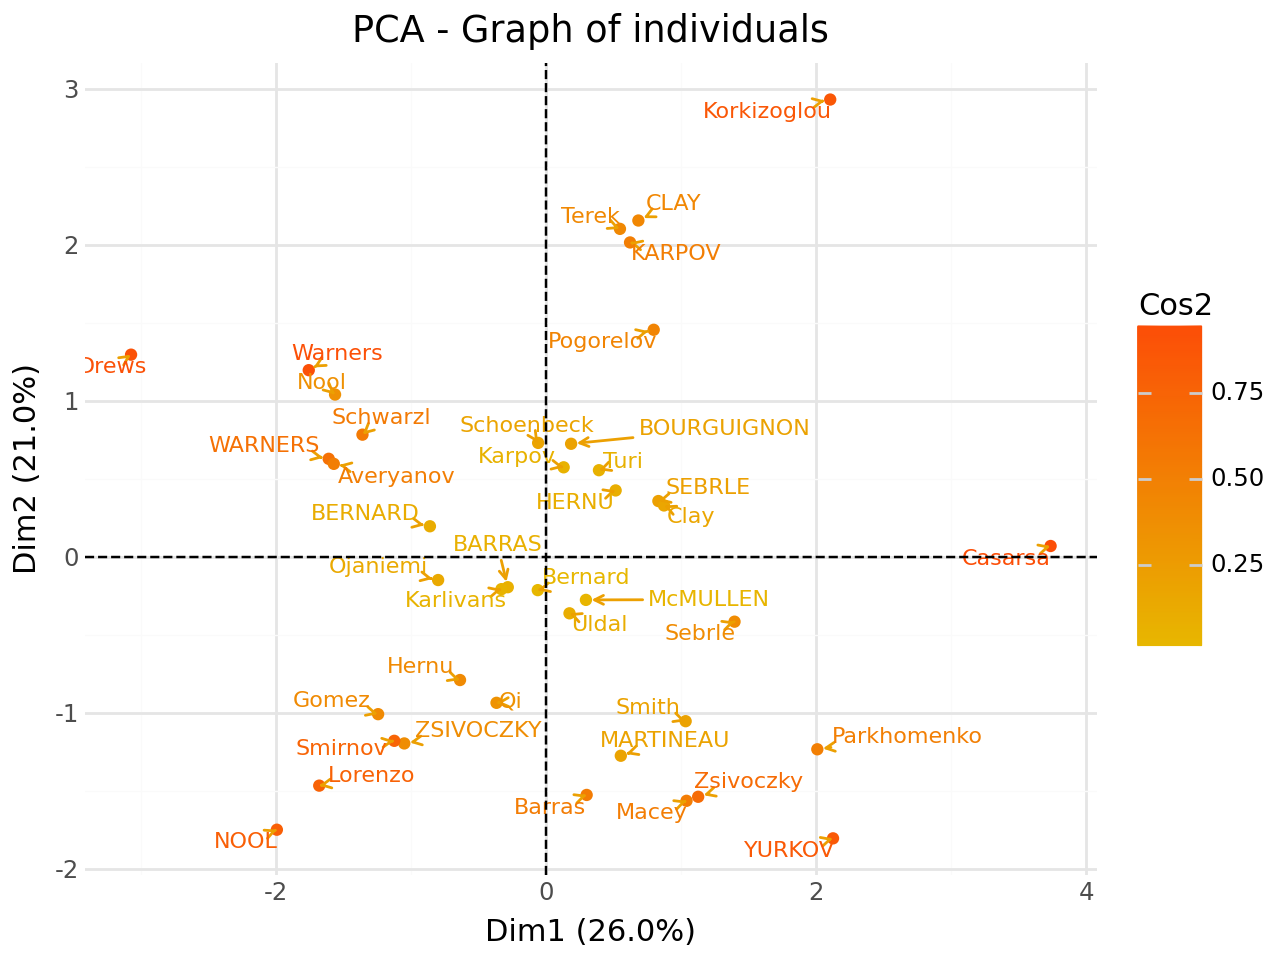

None


In [21]:
# graph of individuals - color by cosinus
p = fviz_pca(
    obj=clf,
    choice="ind",
    col_ind="cos2",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

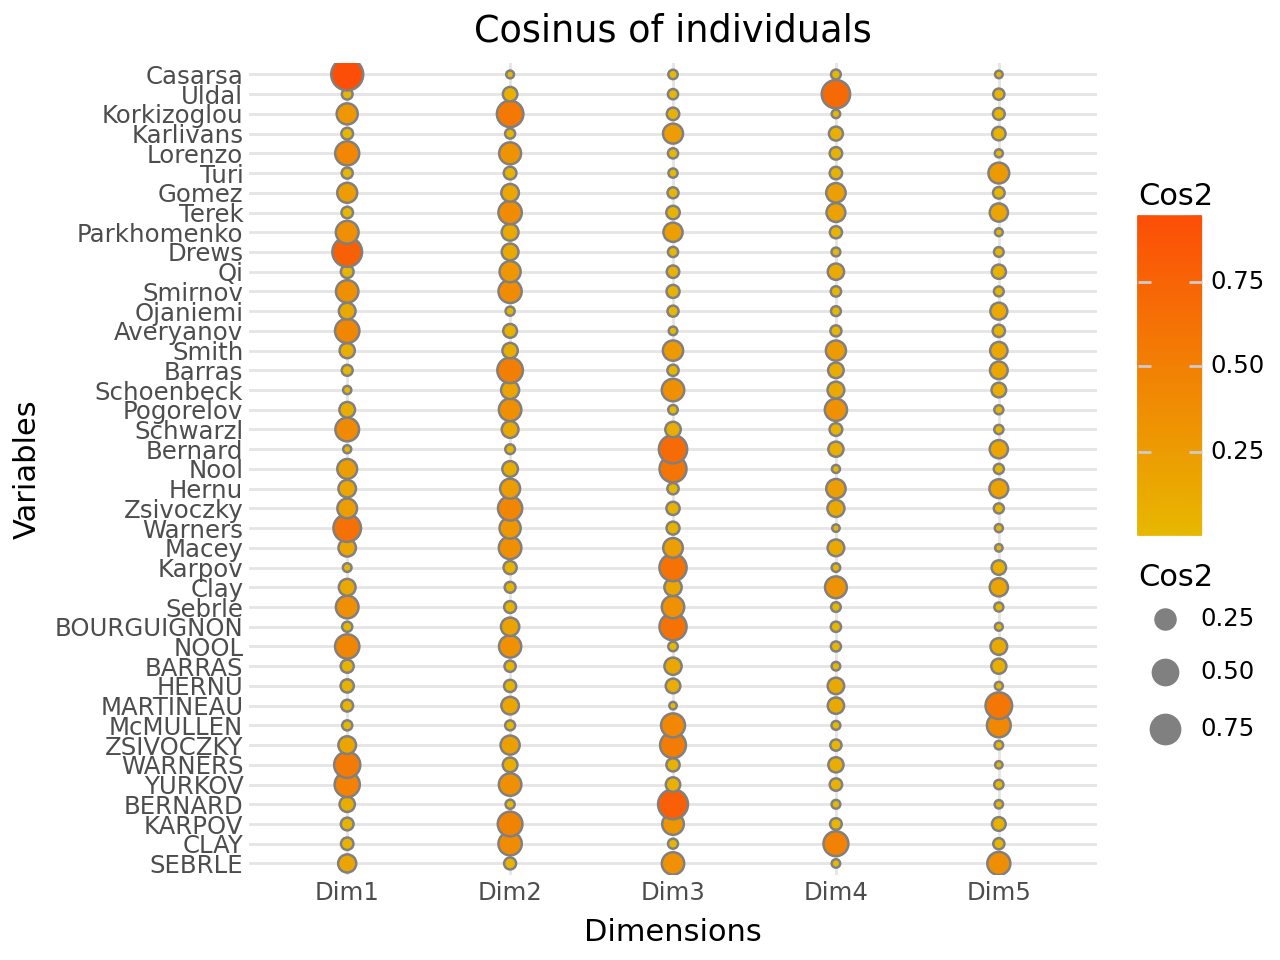

None


In [22]:
# graph of cosinus
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

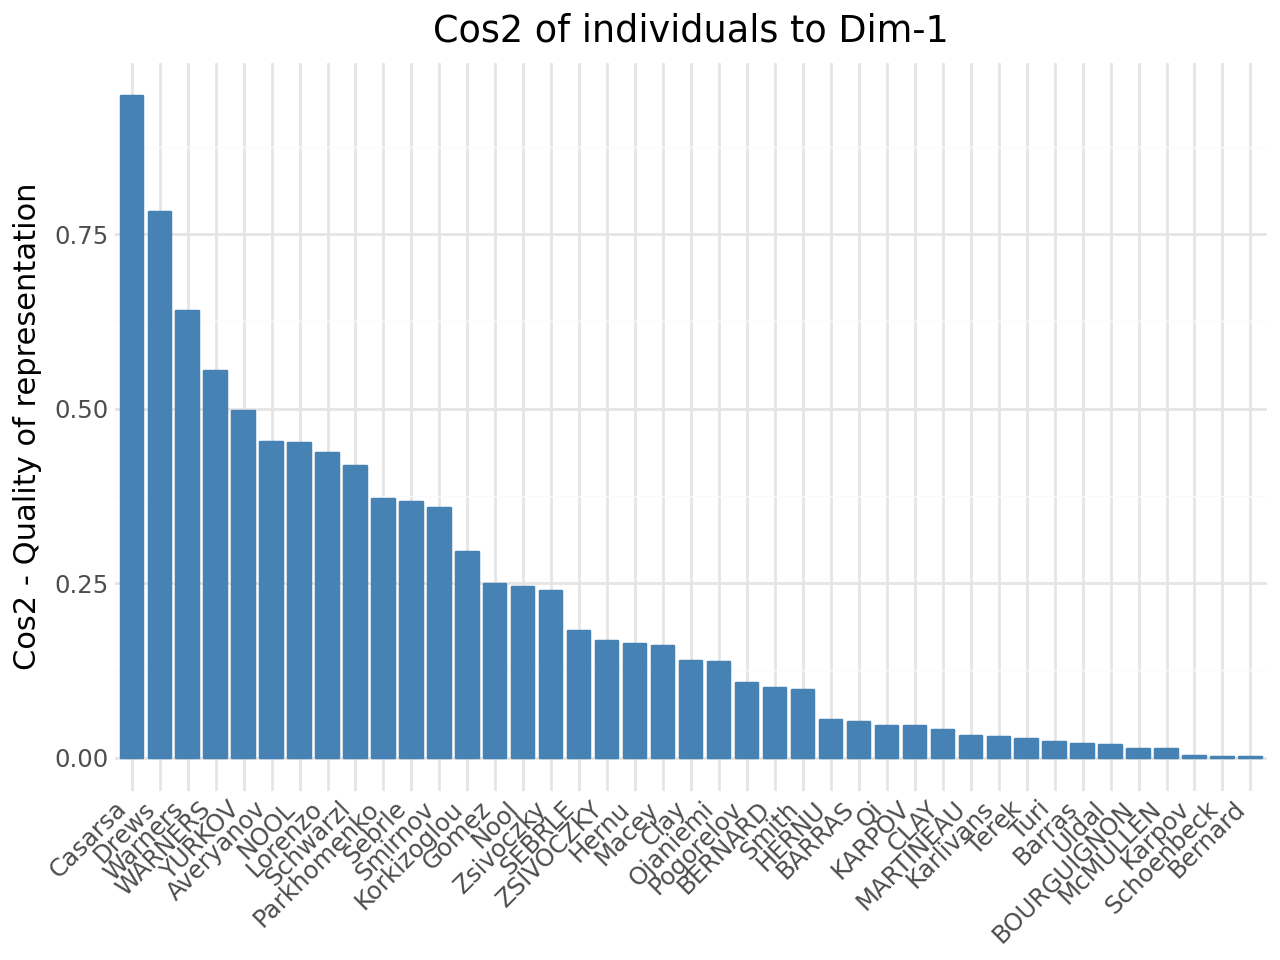

None


In [23]:
# cosinus of individuals to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals additionals informations

In [24]:
# individuals additionals informations (weight,squared distance to origin, inertia)
ind.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
SEBRLE,0.02439,3.795988,0.092585,1.389011
CLAY,0.02439,11.617735,0.283359,4.251111
KARPOV,0.02439,8.595055,0.209635,3.145065
BERNARD,0.02439,7.480485,0.182451,2.737226
YURKOV,0.02439,9.083952,0.221560,3.323960
WARNERS,0.02439,4.686579,0.114307,1.714893
ZSIVOCZKY,0.02439,6.610461,0.161231,2.418871
McMULLEN,0.02439,7.296529,0.177964,2.669914
MARTINEAU,0.02439,10.004982,0.244024,3.660979
HERNU,0.02439,4.922914,0.120071,1.801371


## Variables informations

In [25]:
# variables informations
var = get_pca(clf,"var")
var._fields

('coord', 'cos2', 'contrib', 'infos')

### Variables coordinates

In [26]:
# variables coordinates
var.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
X100m,0.174475,-0.350726,0.147892,0.163895,-0.228431
Long.Jump,-0.323743,0.240279,-0.059441,-0.113978,0.301368
Shot.Put,0.605784,0.022741,0.046304,0.114184,-0.220298
High.Jump,0.362388,-0.223476,-0.272777,0.496152,0.363914
X400m,0.553626,0.053681,0.218381,0.037640,0.209104
X110m.Hurdle,0.208364,-0.243006,0.438205,0.142705,0.075171
Discus,0.623554,0.114309,-0.347947,-0.206677,-0.316686
Pole.Vault,-0.169516,0.547935,0.682963,0.263244,-0.189709
Javeline,0.304579,-0.437165,0.508222,-0.443487,0.208111
X1500m,0.493076,0.774449,-0.017258,-0.114513,0.222063


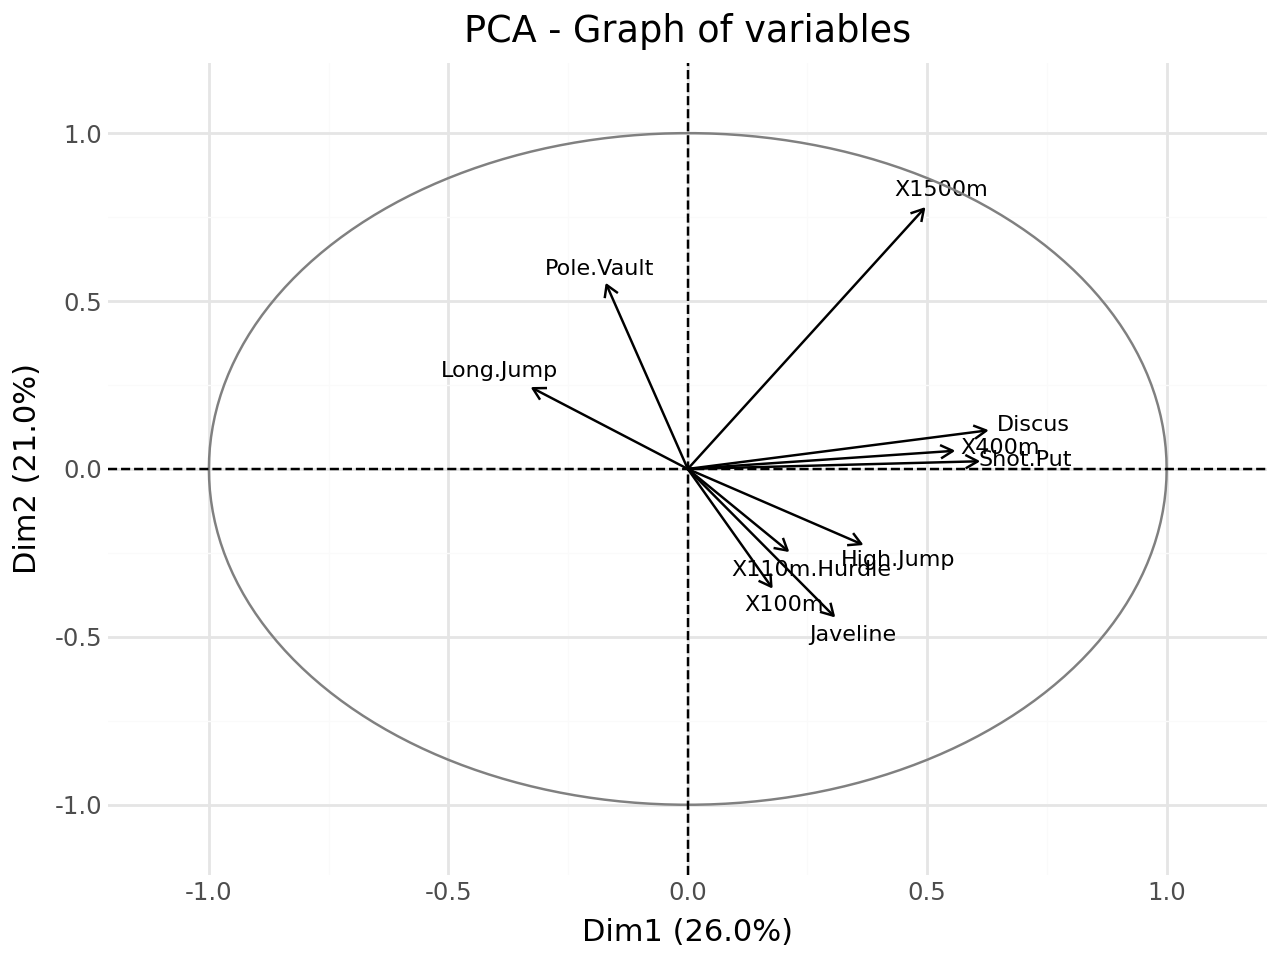

None


In [27]:
# graph of variables - correlation circle
p = fviz_pca(
    obj=clf,
    choice="var",
    repel=True,
    quanti_sup=False
)
print(p.show())

### Variables contributions

In [28]:
# variables contributions
var.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
X100m,1.752616,8.803203,1.841449,4.179858,8.664385
Long.Jump,6.034248,4.131761,0.297467,2.021497,15.080647
Shot.Put,21.127939,0.037011,0.180509,2.028782,8.058402
High.Jump,7.560834,3.574088,6.264508,38.305206,21.989988
X400m,17.646305,0.206225,4.015127,0.220460,7.260235
X110m.Hurdle,2.499580,4.226100,16.166838,3.168873,0.938279
Discus,22.385663,0.935113,10.192869,6.646774,16.652676
Pole.Vault,1.654405,21.486381,39.270280,10.783118,5.975889
Javeline,5.340970,13.677117,21.745877,30.604908,7.191487
X1500m,13.997439,42.923002,0.025077,2.040524,8.188012


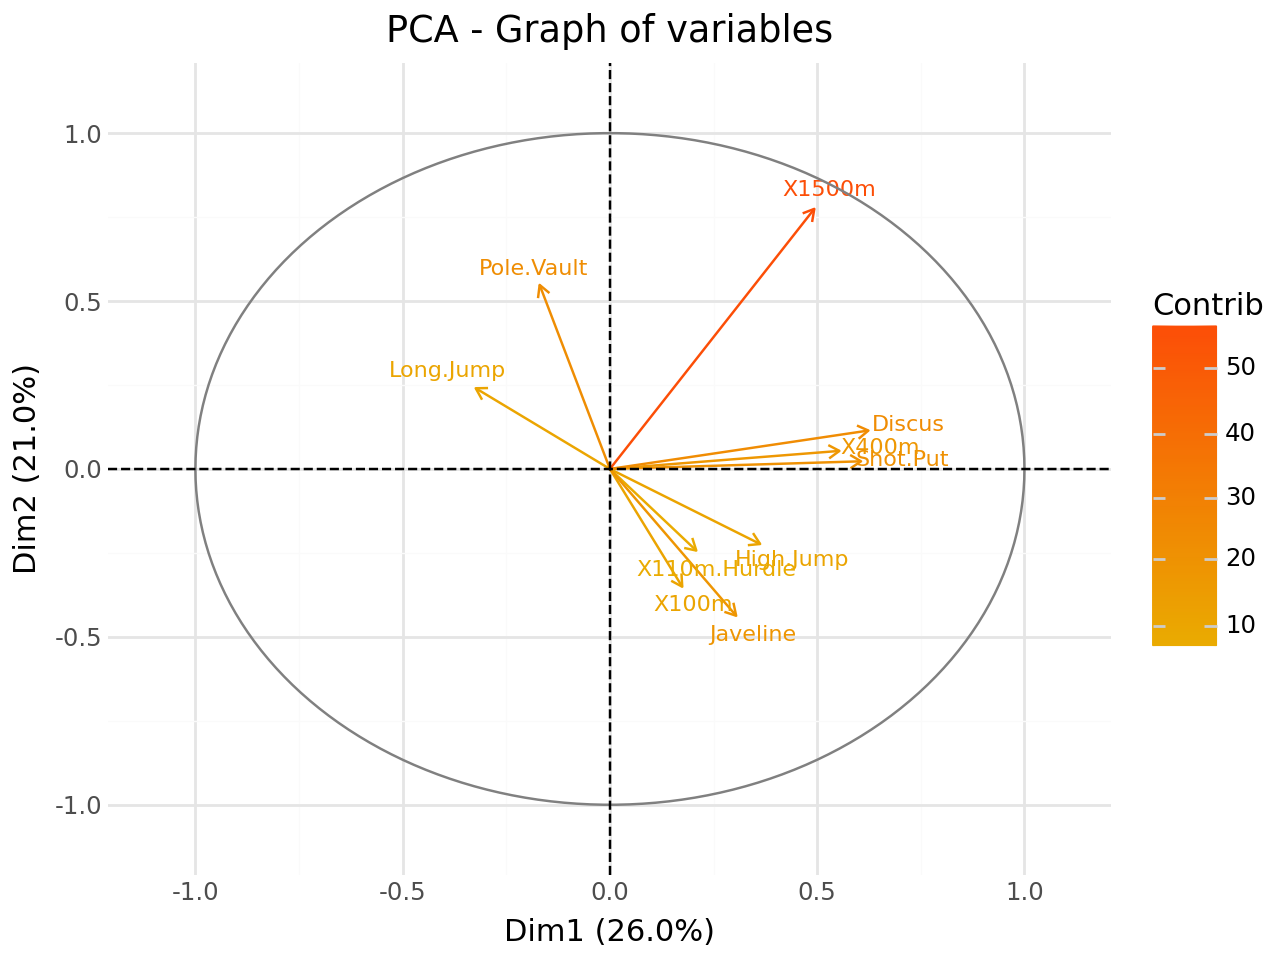

None


In [29]:
# graph of variables - color by contrib
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "contrib",
    repel=True,
    quanti_sup=False
)
print(p.show())

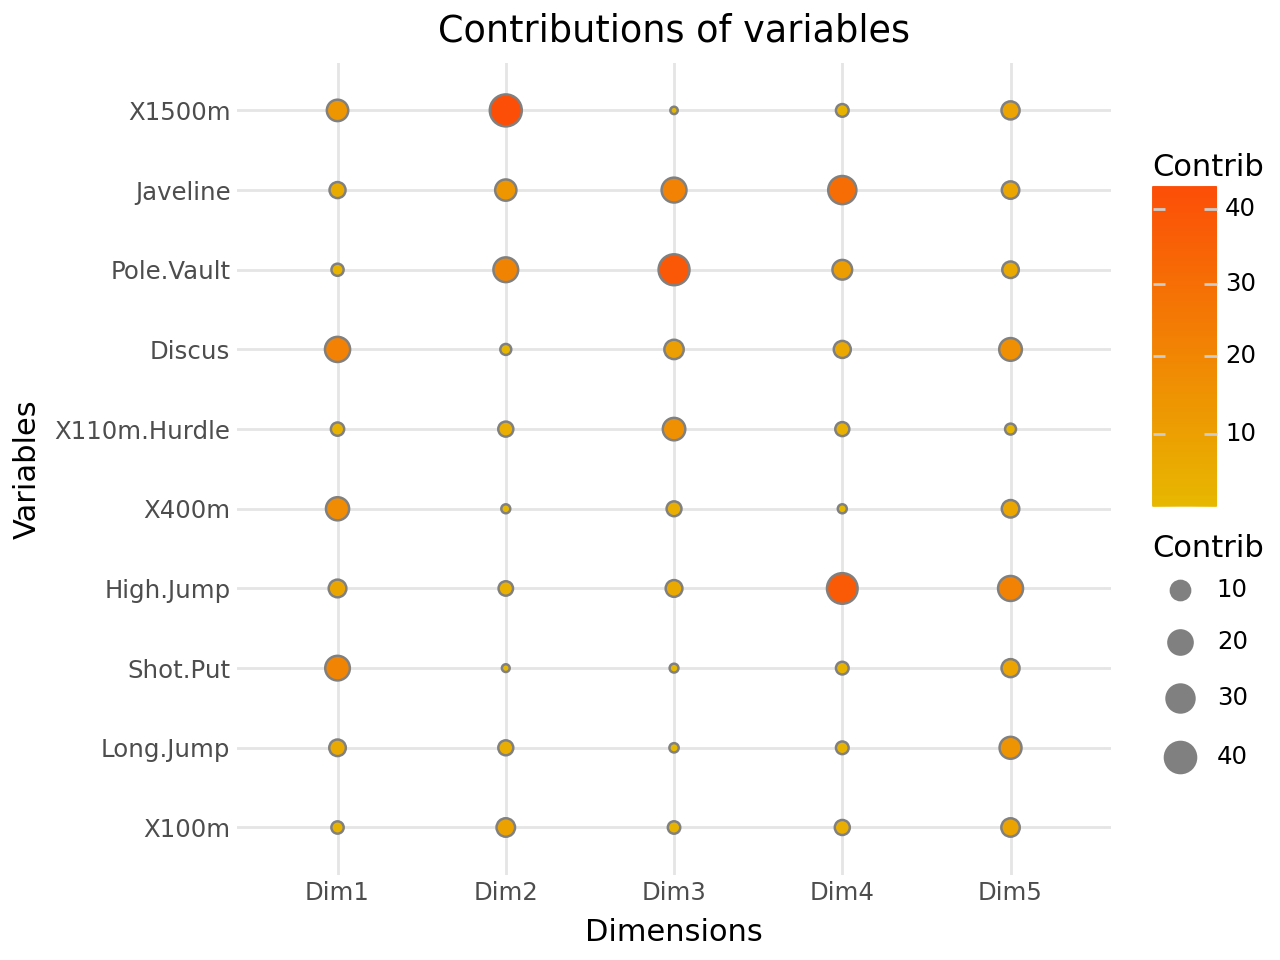

None


In [30]:
# graph of contributions for variables
p = fviz_corrplot(
    X=var.contrib,
    legend_title="Contrib",
    title="Contributions of variables"
)
print(p.show())

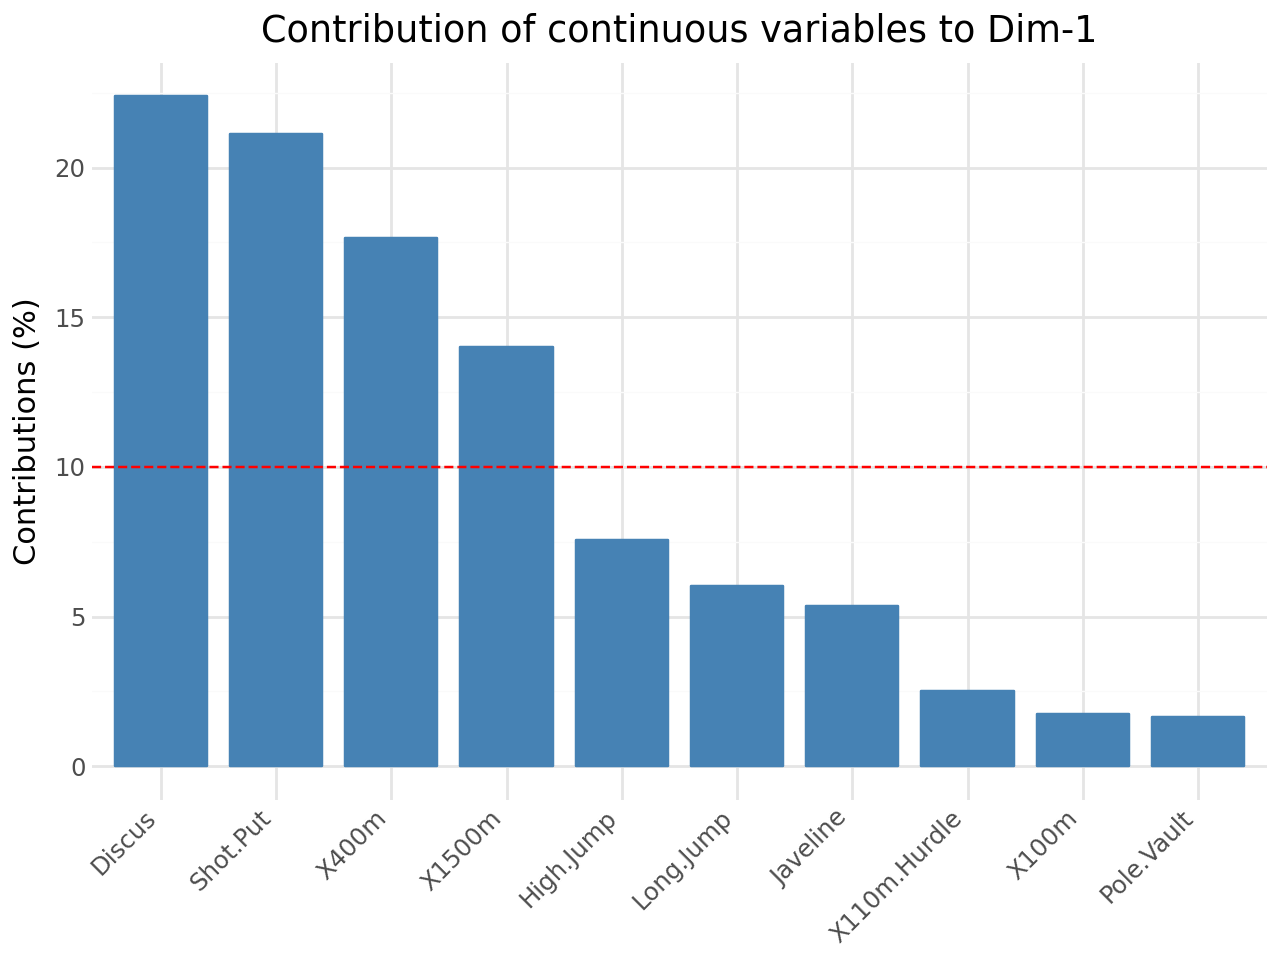

None


In [31]:
# contributions of variables to axis 1
p = fviz_contrib(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables cos2

In [32]:
# variables cos2
var.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
X100m,0.072535,0.293101,0.052116,0.064005,0.124335
Long.Jump,0.228065,0.125628,0.007688,0.028268,0.197628
Shot.Put,0.626557,0.000883,0.003661,0.022260,0.082860
High.Jump,0.201467,0.076615,0.114149,0.377646,0.203167
X400m,0.568867,0.005348,0.088513,0.002630,0.081153
X110m.Hurdle,0.074424,0.101228,0.329171,0.034909,0.009687
Discus,0.511800,0.017199,0.159360,0.056226,0.132011
Pole.Vault,0.031278,0.326793,0.507701,0.075428,0.039173
Javeline,0.114674,0.236241,0.319281,0.243124,0.053537
X1500m,0.258865,0.638603,0.000317,0.013962,0.052505


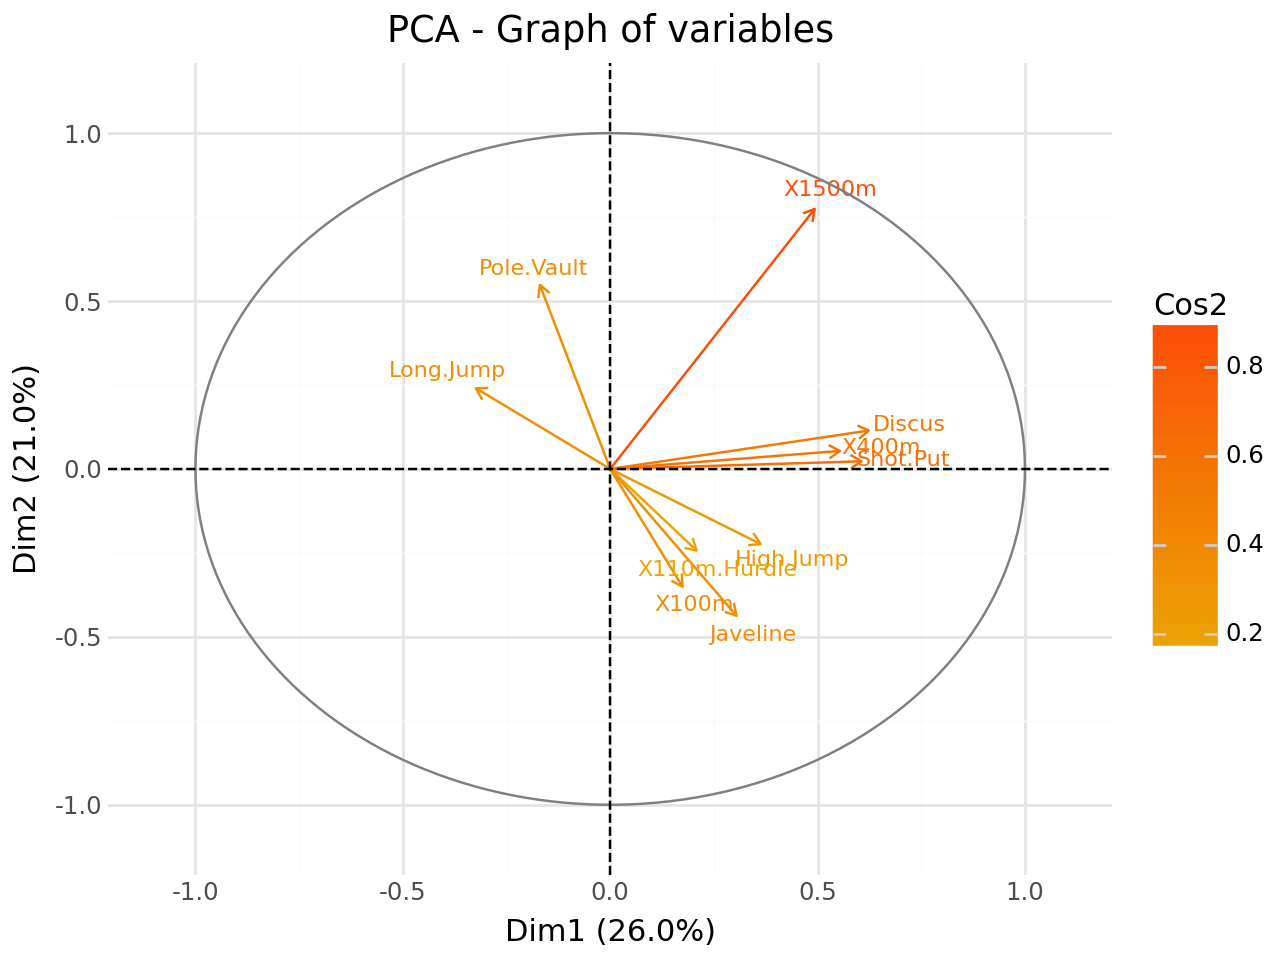

None


In [33]:
# graph of variables - color by cosinus
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "cos2",
    repel=True,
    quanti_sup=False
)
print(p.show())

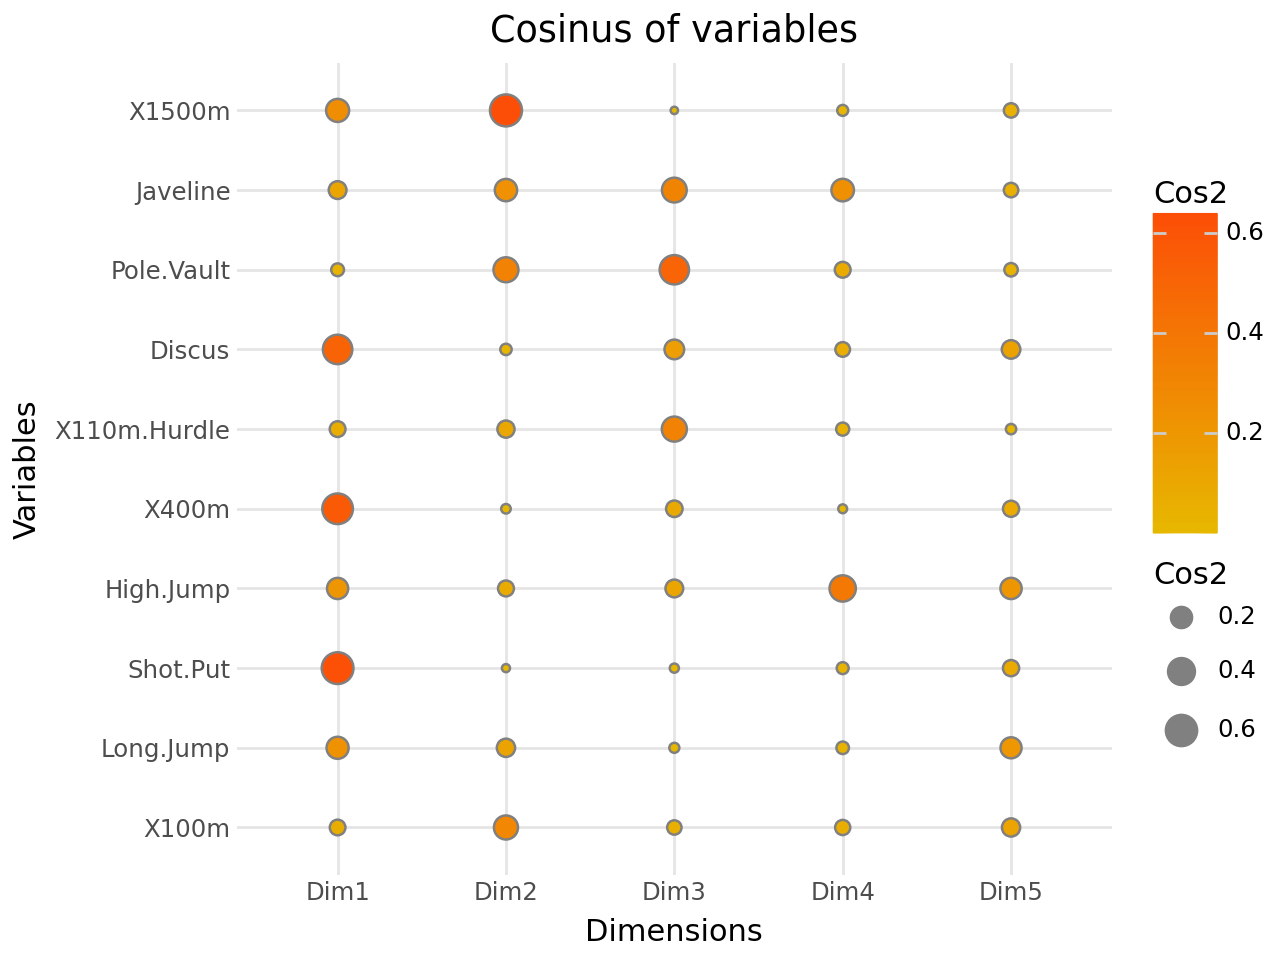

None


In [34]:
# graph of cosinus for variables
p = fviz_corrplot(
    X=var.cos2,
    legend_title="Cos2",
    title="Cosinus of variables"
)
print(p.show())

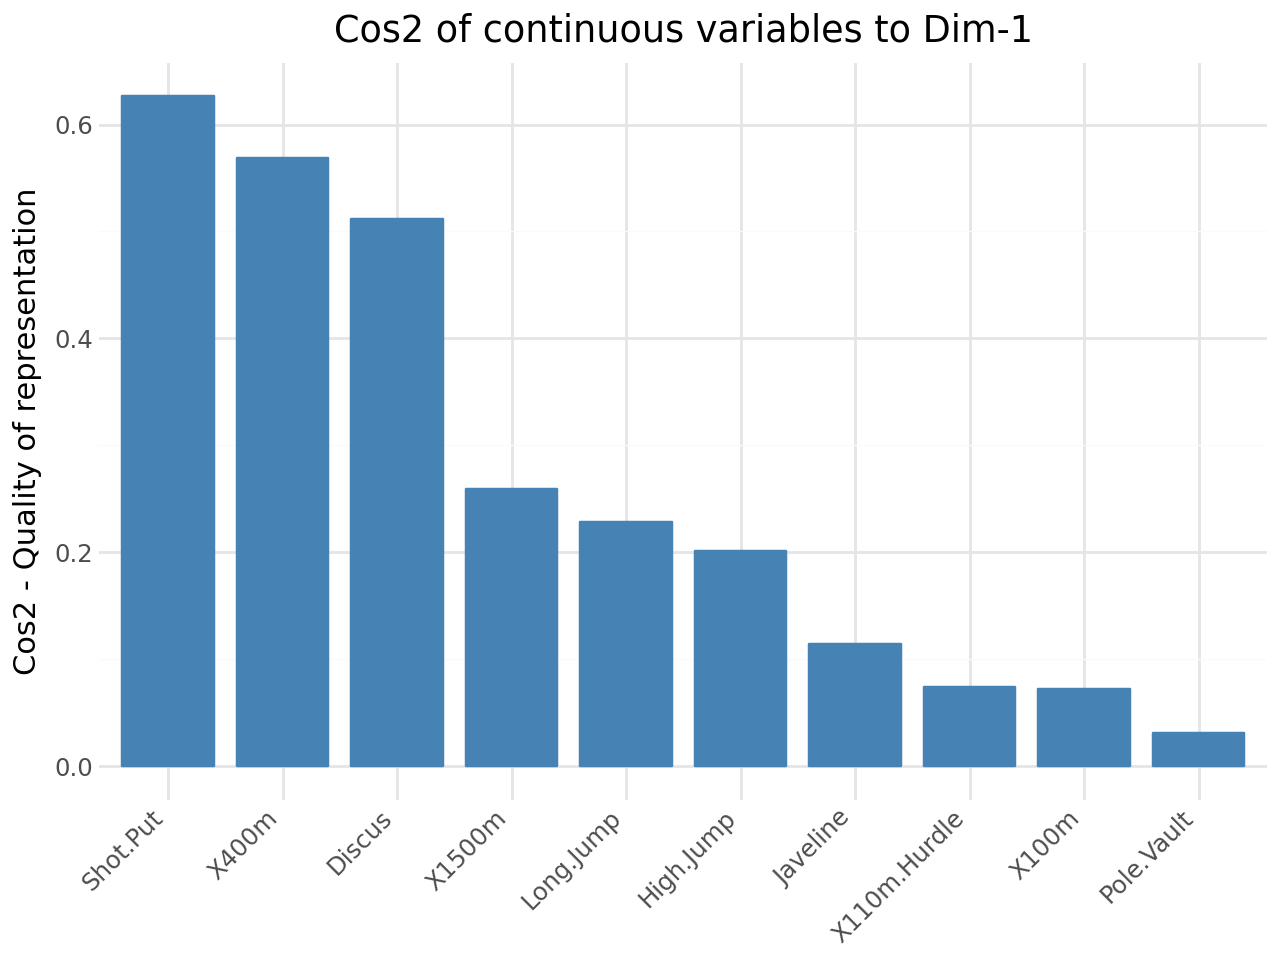

None


In [35]:
# cosinus of variables to axis 1
p = fviz_cos2(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables additionals informations

In [36]:
# variables additionals informations
var.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
X100m,1.0,0.419681,0.419681,6.296275
Long.Jump,1.0,0.459561,0.459561,6.894585
Shot.Put,1.0,0.585700,0.585700,8.786990
High.Jump,1.0,0.651845,0.651845,9.779337
X400m,1.0,0.538793,0.538793,8.083258
X110m.Hurdle,1.0,0.583356,0.583356,8.751819
Discus,1.0,0.759711,0.759711,11.397596
Pole.Vault,1.0,0.918726,0.918726,13.783219
Javeline,1.0,0.808973,0.808973,12.136649
X1500m,1.0,0.939192,0.939192,14.090272


## Summary

In [37]:
# summary
from scientisttools import summary
summary(clf)

                     Principal Component Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      1.7369      0.3396         26.0581         26.0581
Dim2      1.3973      0.2096         20.9633         47.0215
Dim3      1.1878      0.5451         17.8195         64.8409

Individuals (the 10 first):
             Dim1    cos2     ctr    Dim2    cos2     ctr    Dim3    cos2  \
SEBRLE     0.8304  0.1817  0.9684  0.3570  0.0336  0.2225  1.1591  0.3539   
CLAY       0.6823  0.0401  0.6538  2.1553  0.3999  8.1087 -0.3536  0.0108   
KARPOV     0.6207  0.0448  0.5409  2.0148  0.4723  7.0859 -1.6508  0.3171   
BERNARD   -0.8611  0.0991  1.0413  0.1953  0.0051  0.0666  2.4395  0.7956   
YURKOV     2.1235  0.4964  6.3321 -1.8052  0.3587  5.6882  0.8484  0.0792   
WARNERS   -1.6104  0.5534  3.6419  0.6278  0.0841  0.6880 -0.5046  0.0543   
ZSIVOCZKY -1.0510  0.1671  1.5510 -1.1968  0.2167  2.5001 -1.8810  0.5353   
McM

In [38]:
# formatting text to markdown
summary(clf,to_markdown=True)

                     Principal Component Analysis - Results                     

Importance of components:
        Eigenvalue    Difference    Proportion (%)    Cumulative (%)
----  ------------  ------------  ----------------  ----------------
Dim1        1.7369        0.3396           26.0581           26.0581
Dim2        1.3973        0.2096           20.9633           47.0215
Dim3        1.1878        0.5451           17.8195           64.8409

Individuals (the 10 first):
              Dim1    cos2     ctr     Dim2    cos2     ctr     Dim3    cos2      ctr
---------  -------  ------  ------  -------  ------  ------  -------  ------  -------
SEBRLE      0.8304  0.1817  0.9684   0.357   0.0336  0.2225   1.1591  0.3539   2.7588
CLAY        0.6823  0.0401  0.6538   2.1553  0.3999  8.1087  -0.3536  0.0108   0.2567
KARPOV      0.6207  0.0448  0.5409   2.0148  0.4723  7.0859  -1.6508  0.3171   5.5961
BERNARD    -0.8611  0.0991  1.0413   0.1953  0.0051  0.0666   2.4395  0.7956  12.2205
YU